In [4]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [ ]:
import numpy as np
from src.get_data import load_data, get_cell_slice, get_trial_slice
from src.clustering_tools import run_clustering

In [6]:
# X, Y, cell_ids, rec_ids = load_data("data/simulated", "test1.mat")

# X has shape (5 cvovariates, 15000 x 4 subjects = 60000 time bins)
# Y has shape (60000, 1) - one spike count per time bin
# cell_ids uniquely identify each cell across all subjects
# rec_ids uniquely identify each recording
filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_data("../data/simulated", filenames)

In [29]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((5, 60000), (60000,), (60000,), (60000,))

In [7]:
X

array([[-0.64901377,  1.18116604, -0.7584533 , ...,  0.5445917 ,
         0.22682468, -1.08085147],
       [ 0.90001112, -0.42857532,  0.89944987, ..., -1.72436694,
         0.44956979,  0.94353064],
       [-0.43094213, -0.07587645, -1.54328912, ...,  1.38244384,
         1.19434176, -0.11757279],
       [ 0.21489379,  0.33549953, -0.03029765, ...,  0.85432461,
         0.72757149,  2.63936133],
       [ 2.81058991, -0.1099234 ,  1.33210679, ..., -0.79551777,
        -0.21896155, -1.3196753 ]])

In [8]:
Y

array([0., 5., 0., ..., 0., 0., 0.])

In [9]:
cell_ids

array([ 0.,  0.,  0., ..., 49., 49., 49.])

In [12]:
np.unique(cell_ids, return_counts=True)

(array([ 0.,  1.,  2.,  3.,  4., 10., 11., 12., 13., 14., 25., 26., 27.,
        28., 29., 45., 46., 47., 48., 49.]),
 array([3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000,
        3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000], dtype=int64))

In [13]:
np.unique(cell_ids).shape

(20,)

In [14]:
rec_ids

array([ 1.,  1.,  1., ..., 13., 13., 13.])

In [15]:
# unique values + counts
np.unique(rec_ids, return_counts=True)

(array([ 1.,  4.,  8., 13.]), array([15000, 15000, 15000, 15000], dtype=int64))

In [16]:
n_features, n_time_x = X.shape
(n_time_y,) = Y.shape

In [17]:
n_features, n_time_x, n_time_y

(5, 60000, 60000)

In [18]:
# For each test subject (4 subjects):
# There are 5 cells, each with 3000 time bins → total 15000 time bins.
# •  Y is all spike counts concatenated across cells:
# • 	first 3000 entries → cell 0
# • 	next 3000 → cell 1
# • 	etc.
# •  X has 5 covariates (features), each sampled over 15000 time bins.

# You already have the key:
# • 	5 cells × 3000 time bins = 15000
# • 	120 repeated trials
# So for each cell:
# • 	3000 time bins
# • 	3000 / 120 = 25 time bins per trial
# So the structure is:
# • 	Per cell: 120 trials × 25 time bins
# • 	Per time bin: 5 covariates in X, 1 spike count in Y
n_cells = 5
bins_per_cell = 3000
trials_per_cell = 120
bins_per_trial = bins_per_cell // trials_per_cell  # 25

# sanity check
assert n_cells * bins_per_cell * 4 == X.shape[1] == Y.shape[0]

In [19]:
# 3. How to isolate data per cell
cell_idx = 0  # 0..4

cell_slice = get_cell_slice(cell_idx, cell_ids)
X_cell = X[:, cell_slice]  # shape: (5, 3000)
Y_cell = Y[cell_slice]  # shape: (3000,)

In [20]:
X_cell, Y_cell

(array([[-0.64901377,  1.18116604, -0.7584533 , ...,  0.5445917 ,
          0.22682468, -1.08085147],
        [ 0.90001112, -0.42857532,  0.89944987, ..., -1.72436694,
          0.44956979,  0.94353064],
        [-0.43094213, -0.07587645, -1.54328912, ...,  1.38244384,
          1.19434176, -0.11757279],
        [ 0.21489379,  0.33549953, -0.03029765, ...,  0.85432461,
          0.72757149,  2.63936133],
        [ 2.81058991, -0.1099234 ,  1.33210679, ..., -0.79551777,
         -0.21896155, -1.3196753 ]]),
 array([0., 5., 0., ..., 0., 1., 0.]))

In [21]:
# 4. How to isolate data per trial (within a cell)
# Within a cell:
# • 	3000 time bins
# • 	120 trials
# • 	25 bins per trial
cell_idx = 0  # 0..4
trial_idx = 10  # 0..119

trial_slice = get_trial_slice(cell_idx, trial_idx, cell_ids)
X_trial = X[:, trial_slice]  # shape: (5, 25)
Y_trial = Y[trial_slice]  # shape: (25,)

In [22]:
X_trial, Y_trial

(array([[-8.23197262e-01,  3.31905598e-01,  3.43913883e-01,
          3.79747972e-01,  1.08893930e+00,  9.94859162e-01,
          2.08609505e-01, -3.99187785e-01,  5.06010998e-01,
         -1.27763460e-01, -2.54920829e-01, -7.80433484e-02,
         -3.14649337e-01, -3.08418402e-01,  4.01268224e-01,
         -1.29420672e-01,  1.32768323e+00,  6.70786507e-01,
         -6.91714890e-01, -4.92184407e-02, -3.26730968e-01,
          3.03248303e-01,  2.05650030e+00,  1.70719108e+00,
          5.10741754e-01],
        [-1.50430359e-01, -7.51237323e-01,  8.98460587e-02,
          2.67783090e+00, -8.69180423e-04, -9.40429290e-02,
          1.25418774e+00,  1.09454248e+00, -5.73717761e-01,
          1.58221195e+00,  1.51005907e+00, -1.05657509e+00,
          8.40914644e-02,  5.81723830e-01, -3.33396044e-01,
         -8.71868731e-02,  7.77258543e-01, -1.29389632e+00,
         -4.49303801e-01,  2.92758698e-01, -9.17028830e-01,
          1.60882242e+00,  4.97901343e-01,  1.14063957e+00,
          4.6

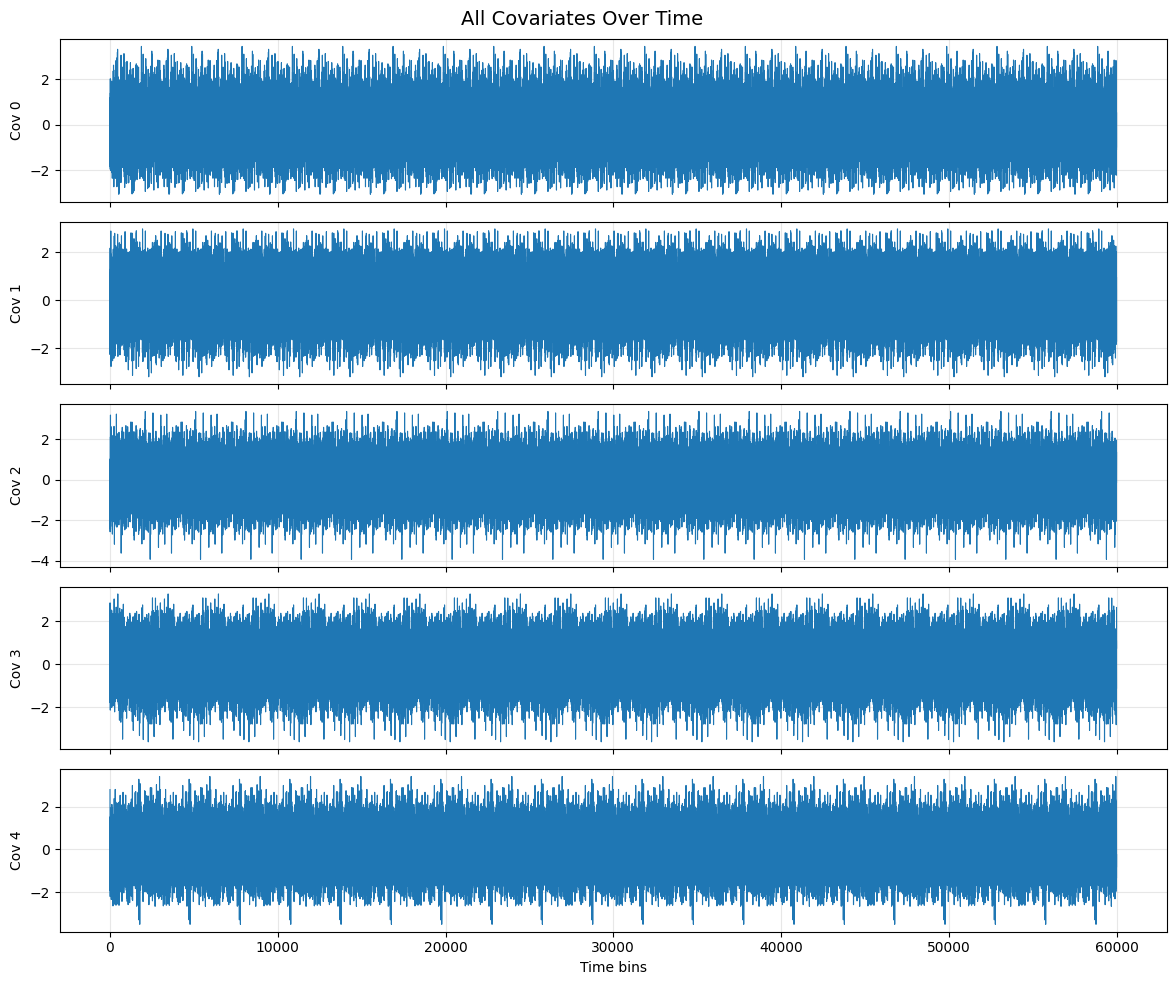

In [23]:
# Plot all covariates across the full recording
def plot_all_covariates(X):
    n_cov = X.shape[0]
    fig, axes = plt.subplots(n_cov, 1, figsize=(12, 2 * n_cov), sharex=True)

    for i in range(n_cov):
        axes[i].plot(X[i], linewidth=0.8)
        axes[i].set_ylabel(f"Cov {i}")
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time bins")
    plt.suptitle("All Covariates Over Time", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_all_covariates(X)

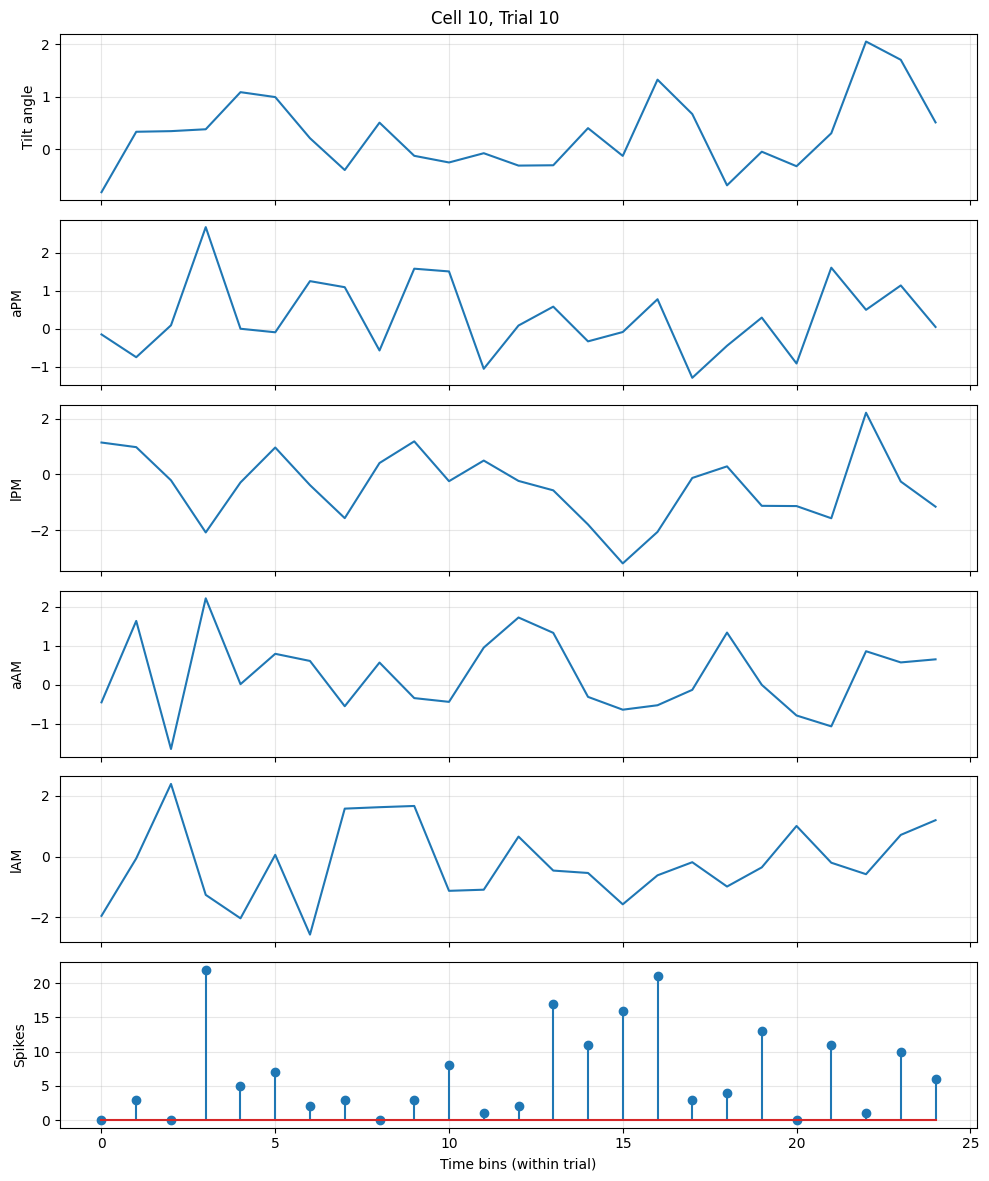

In [24]:
# Plot covariates for a single cell and trial
# Covariate index	Meaning
# 0	Tilt angle
# 1	aPM (angular passive head speed)
# 2	lPM (linear passive head speed)
# 3	aAM (angular active head speed)
# 4	lAM (linear active head speed)
def plot_covariates_and_spikes(X, Y, cell_ids, cell_idx, trial_idx):
    sl = get_trial_slice(cell_idx, trial_idx, cell_ids)
    X_trial = X[:, sl]
    Y_trial = Y[sl]

    cov_names = ["Tilt angle", "aPM", "lPM", "aAM", "lAM"]

    n_cov = X_trial.shape[0]
    fig, axes = plt.subplots(n_cov + 1, 1, figsize=(10, 2 * (n_cov + 1)), sharex=True)

    for i in range(n_cov):
        axes[i].plot(X_trial[i])
        axes[i].set_ylabel(cov_names[i])
        axes[i].grid(True, alpha=0.3)

    axes[-1].stem(Y_trial)
    axes[-1].set_ylabel("Spikes")
    axes[-1].set_xlabel("Time bins (within trial)")
    axes[-1].grid(True, alpha=0.3)

    plt.suptitle(f"Cell {cell_idx}, Trial {trial_idx}")
    plt.tight_layout()
    plt.show()


# Example call
plot_covariates_and_spikes(X, Y, cell_ids, cell_idx=10, trial_idx=10)


Correlation Features (KMeans Clustering) (correlation, kmeans) report:
Cluster 2: cells [0, 1, 2, 3, 4]
Cluster 1: cells [10, 11, 12, 13, 14]
Cluster 0: cells [25, 26, 27, 28, 29]
Cluster 3: cells [45, 46, 47, 48, 49]
Silhouette score: 0.962

Suggested functional labels:
Cluster 0: Strongly tuned to Covariate 2 (positive)
Cluster 1: Strongly tuned to Covariate 1 (positive)
Cluster 2: Strongly tuned to Covariate 3 (negative)
Cluster 3: Strongly tuned to Covariate 2 (negative)


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'features': array([[-0.01816255, -0.05190197,  0.28095931, -0.33970072,  0.1712106 ],
        [-0.02556836, -0.05417702,  0.27781557, -0.33636037,  0.17759378],
        [-0.02006924, -0.05658754,  0.28550425, -0.34349335,  0.17091985],
        [-0.02700574, -0.0580218 ,  0.27222978, -0.3403556 ,  0.17607405],
        [-0.01501685, -0.04603758,  0.27882345, -0.33968557,  0.17040509],
        [ 0.19235693,  0.41142338, -0.37351571,  0.0645596 , -0.25774821],
        [ 0.22682618,  0.43262713, -0.37183155,  0.04298369, -0.26757504],
        [ 0.21396744,  0.39332746, -0.39926575,  0.04460651, -0.23985819],
        [ 0.19061726,  0.42675321, -0.37799323,  0.04022512, -0.26884779],
        [ 0.23883266,  0.42523504, -0.34342252,  0.04129031, -0.28544854],
        [-0.06798414,  0.04853024,  0.2396117 ,  0.16344918, -0.17556049],
        [-0.06749025,  0.05272408,  0.23333308,  0.16350407, -0.17250151],
        [-0.06687295,  0.05115944,  0.23433986,  0.15719004, -0.17339548],
        [-0.0

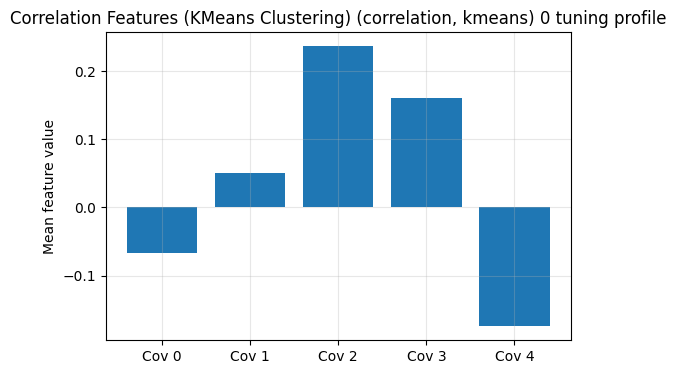

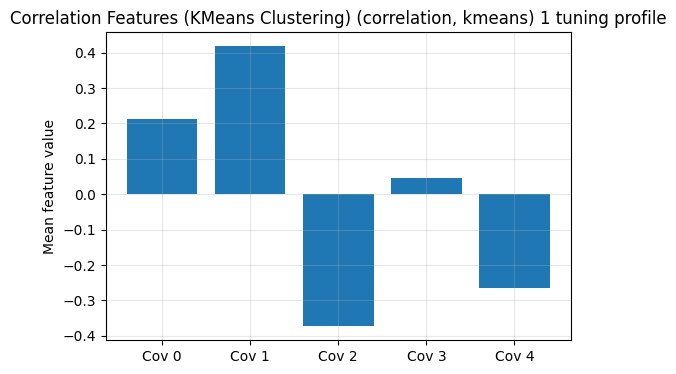

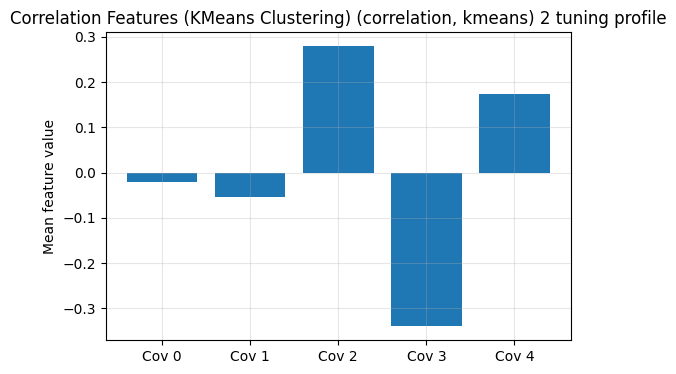

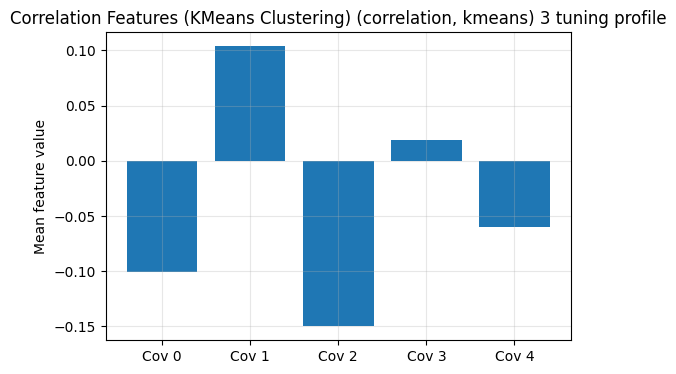

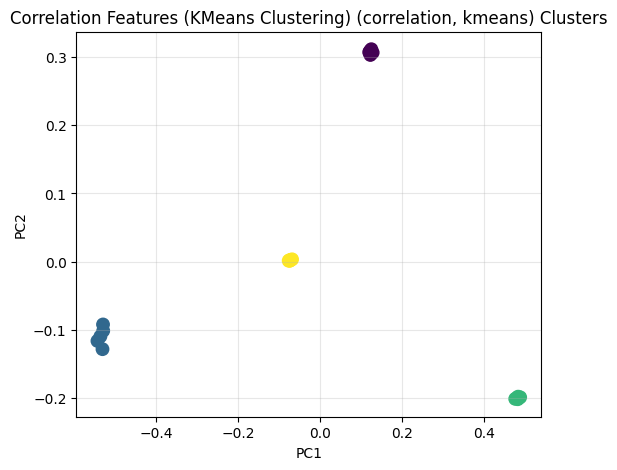

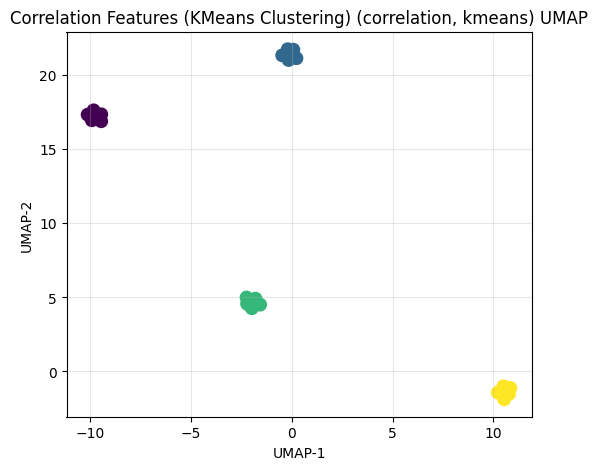

In [ ]:
# Correlation features + KMeans
results_corr_km = run_clustering(
    X,
    Y,
    cell_ids,
    rec_ids,
    feature_key="correlation",
    cluster_key="kmeans",
    n_clusters=4,
    title_prefix="Correlation Features (KMeans Clustering)",
)

results_corr_km


GLM Weight Features (KMeans Clustering) (glm, kmeans) report:
Cluster 2: cells [0, 1, 2, 3, 4]
Cluster 3: cells [10, 11, 12, 13, 14]
Cluster 0: cells [25, 26, 27, 28, 29]
Cluster 1: cells [45, 46, 47, 48, 49]
Silhouette score: 0.974

Suggested functional labels:
Cluster 0: Strongly tuned to Covariate 2 (positive)
Cluster 1: Strongly tuned to Covariate 2 (negative)
Cluster 2: Strongly tuned to Covariate 3 (negative)
Cluster 3: Strongly tuned to Covariate 1 (positive)


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'features': array([[-0.05089858, -0.1845523 ,  0.63788756, -0.76402554,  0.39484665],
        [-0.06763555, -0.18983114,  0.63152407, -0.75769714,  0.4094575 ],
        [-0.05421813, -0.19059822,  0.62972436, -0.75123309,  0.38270364],
        [-0.07027508, -0.19667184,  0.61189328, -0.75747614,  0.40087161],
        [-0.04250099, -0.1666111 ,  0.62200146, -0.75040148,  0.38667778],
        [ 0.20350167,  0.44647838, -0.38519059,  0.05630401, -0.2721836 ],
        [ 0.22646116,  0.44692183, -0.36630603,  0.03312154, -0.26981866],
        [ 0.22219524,  0.4220804 , -0.40790194,  0.03513195, -0.24967397],
        [ 0.20029943,  0.45799342, -0.38608008,  0.03156565, -0.28101369],
        [ 0.23588054,  0.4371277 , -0.33634614,  0.03208884, -0.28621389],
        [-0.33669697, -0.02751713,  1.64189291,  1.35736275, -1.17971811],
        [-0.34063767, -0.00668623,  1.63135309,  1.38847124, -1.19015345],
        [-0.34207544, -0.01206296,  1.64808574,  1.34701073, -1.19824387],
        [-0.3

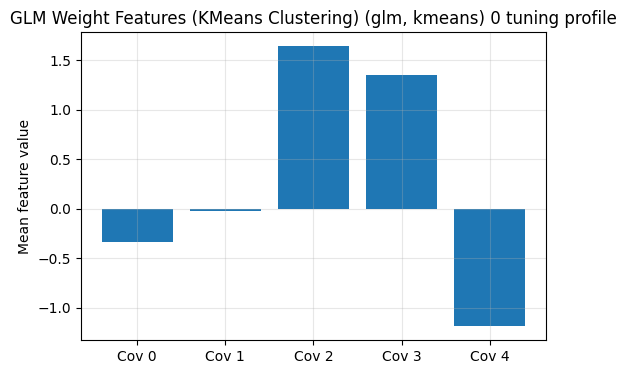

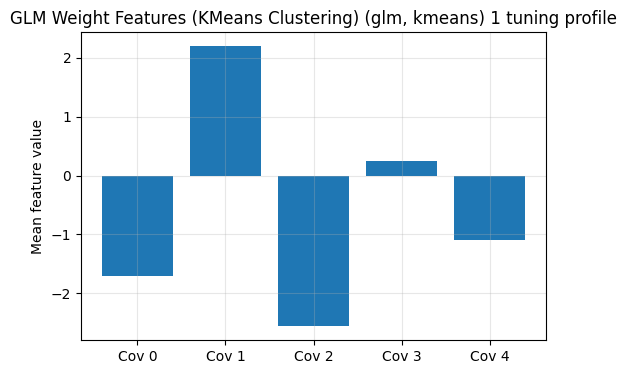

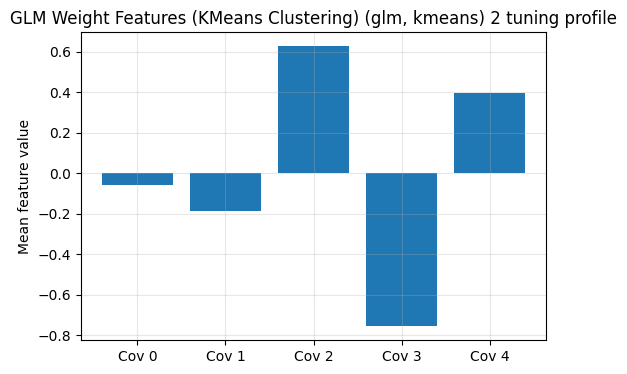

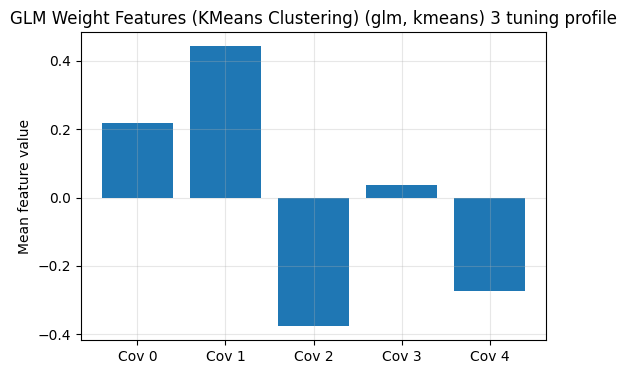

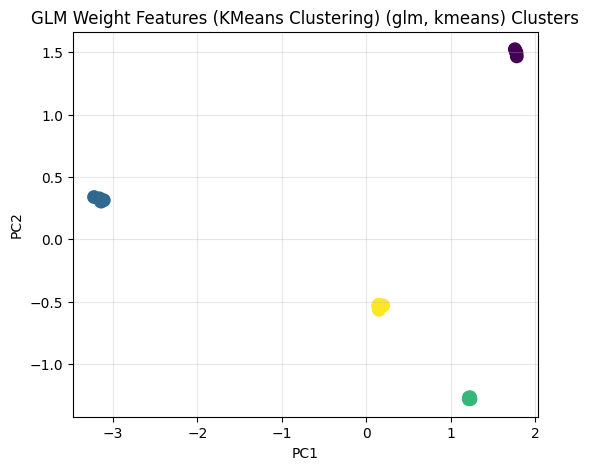

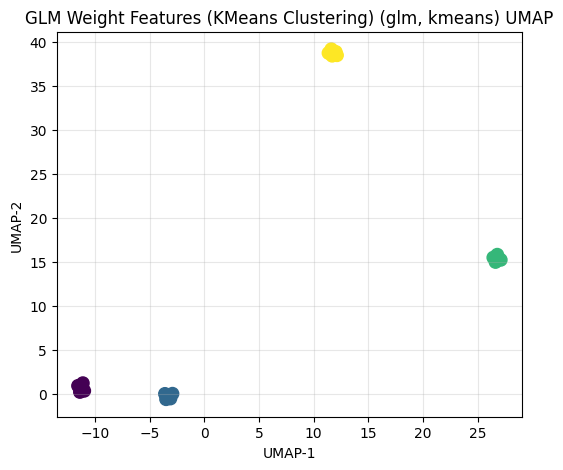

In [26]:
# GLM features + KMeans
results_glm_km = run_clustering(
    X,
    Y,
    cell_ids,
    rec_ids,
    feature_key="glm",
    cluster_key="kmeans",
    n_clusters=4,
    title_prefix="GLM Weight Features (KMeans Clustering)",
)

results_glm_km


Correlation Features (Hierarchical Clustering) (correlation, hierarchical) report:
Cluster 3: cells [0, 1, 2, 3, 4]
Cluster 2: cells [10, 12, 13]
Cluster 1: cells [11, 14]
Cluster 4: cells [25, 26, 27, 28, 29]
Cluster 5: cells [45, 46, 47, 48, 49]
Silhouette score: 0.808

Suggested functional labels:
Cluster 1: Strongly tuned to Covariate 1 (positive)
Cluster 2: Strongly tuned to Covariate 1 (positive)
Cluster 3: Strongly tuned to Covariate 3 (negative)
Cluster 4: Strongly tuned to Covariate 2 (positive)
Cluster 5: Strongly tuned to Covariate 2 (negative)


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'features': array([[-0.01816255, -0.05190197,  0.28095931, -0.33970072,  0.1712106 ],
        [-0.02556836, -0.05417702,  0.27781557, -0.33636037,  0.17759378],
        [-0.02006924, -0.05658754,  0.28550425, -0.34349335,  0.17091985],
        [-0.02700574, -0.0580218 ,  0.27222978, -0.3403556 ,  0.17607405],
        [-0.01501685, -0.04603758,  0.27882345, -0.33968557,  0.17040509],
        [ 0.19235693,  0.41142338, -0.37351571,  0.0645596 , -0.25774821],
        [ 0.22682618,  0.43262713, -0.37183155,  0.04298369, -0.26757504],
        [ 0.21396744,  0.39332746, -0.39926575,  0.04460651, -0.23985819],
        [ 0.19061726,  0.42675321, -0.37799323,  0.04022512, -0.26884779],
        [ 0.23883266,  0.42523504, -0.34342252,  0.04129031, -0.28544854],
        [-0.06798414,  0.04853024,  0.2396117 ,  0.16344918, -0.17556049],
        [-0.06749025,  0.05272408,  0.23333308,  0.16350407, -0.17250151],
        [-0.06687295,  0.05115944,  0.23433986,  0.15719004, -0.17339548],
        [-0.0

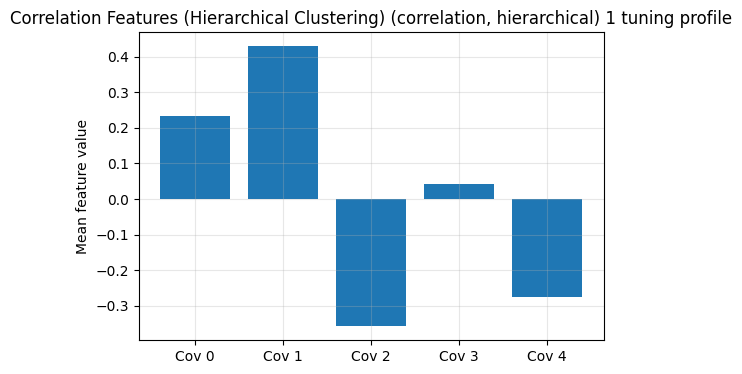

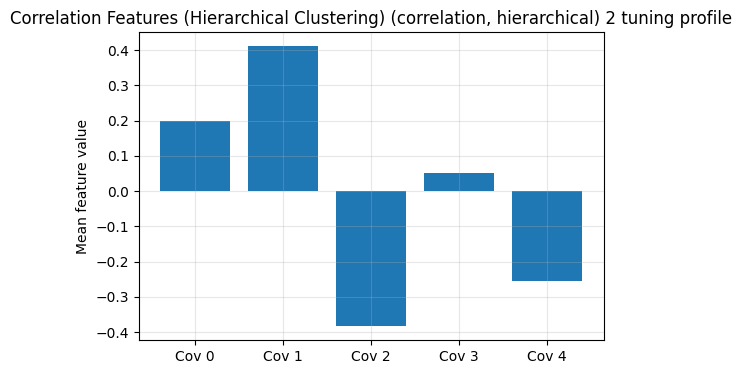

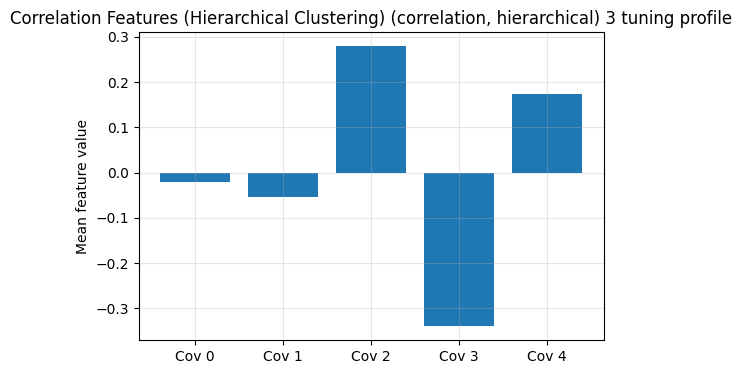

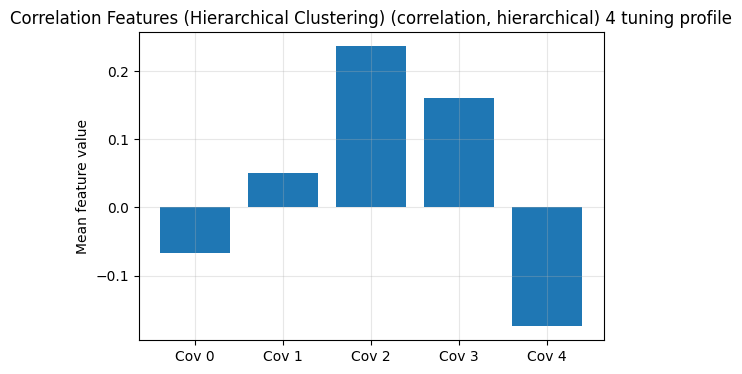

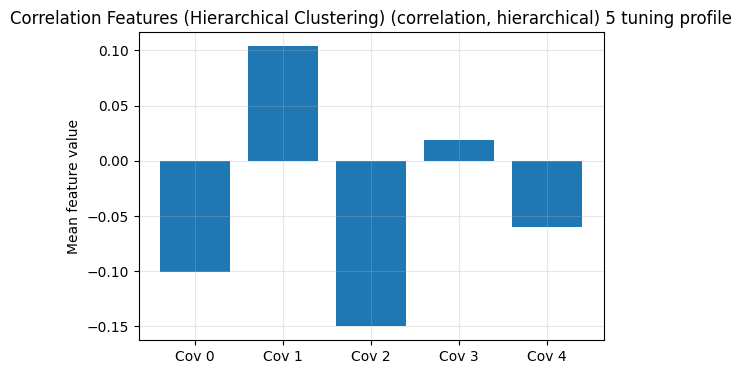

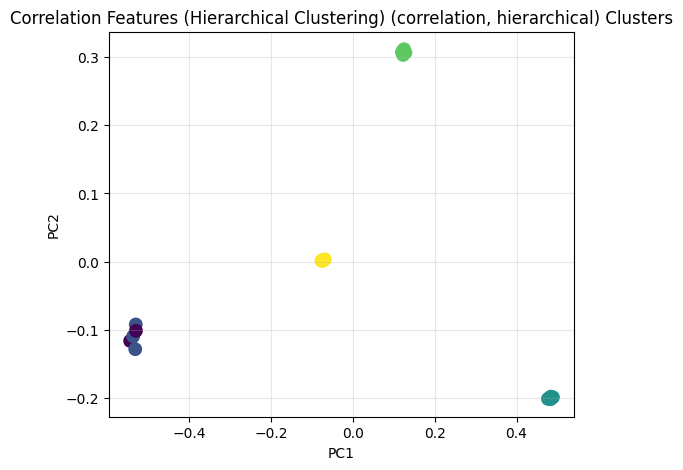

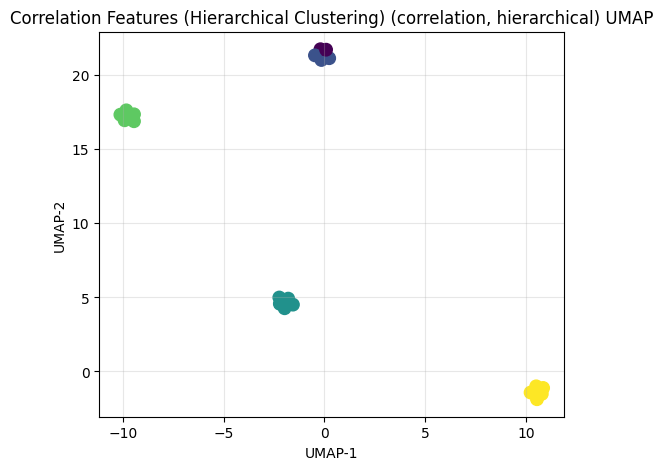

In [27]:
# Correlation features + Hierarchical Clustering
results_corr_hier = run_clustering(
    X,
    Y,
    cell_ids,
    rec_ids,
    feature_key="correlation",
    cluster_key="hierarchical",
    n_clusters=5,
    title_prefix="Correlation Features (Hierarchical Clustering)",
)

results_corr_hier


GLM Weight Features (Hierarchical Clustering) (glm, hierarchical) report:
Cluster 4: cells [0, 1, 2, 3, 4]
Cluster 5: cells [10, 11, 12, 13, 14]
Cluster 3: cells [25, 26, 27, 28, 29]
Cluster 2: cells [45, 47]
Cluster 1: cells [46, 48, 49]
Silhouette score: 0.849

Suggested functional labels:
Cluster 1: Strongly tuned to Covariate 2 (negative)
Cluster 2: Strongly tuned to Covariate 2 (negative)
Cluster 3: Strongly tuned to Covariate 2 (positive)
Cluster 4: Strongly tuned to Covariate 3 (negative)
Cluster 5: Strongly tuned to Covariate 1 (positive)


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'features': array([[-0.05089858, -0.1845523 ,  0.63788756, -0.76402554,  0.39484665],
        [-0.06763555, -0.18983114,  0.63152407, -0.75769714,  0.4094575 ],
        [-0.05421813, -0.19059822,  0.62972436, -0.75123309,  0.38270364],
        [-0.07027508, -0.19667184,  0.61189328, -0.75747614,  0.40087161],
        [-0.04250099, -0.1666111 ,  0.62200146, -0.75040148,  0.38667778],
        [ 0.20350167,  0.44647838, -0.38519059,  0.05630401, -0.2721836 ],
        [ 0.22646116,  0.44692183, -0.36630603,  0.03312154, -0.26981866],
        [ 0.22219524,  0.4220804 , -0.40790194,  0.03513195, -0.24967397],
        [ 0.20029943,  0.45799342, -0.38608008,  0.03156565, -0.28101369],
        [ 0.23588054,  0.4371277 , -0.33634614,  0.03208884, -0.28621389],
        [-0.33669697, -0.02751713,  1.64189291,  1.35736275, -1.17971811],
        [-0.34063767, -0.00668623,  1.63135309,  1.38847124, -1.19015345],
        [-0.34207544, -0.01206296,  1.64808574,  1.34701073, -1.19824387],
        [-0.3

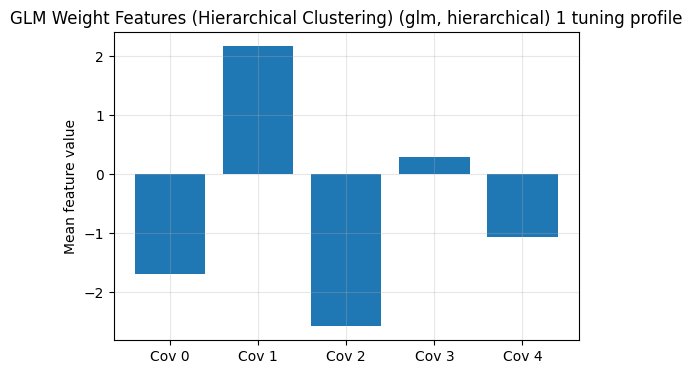

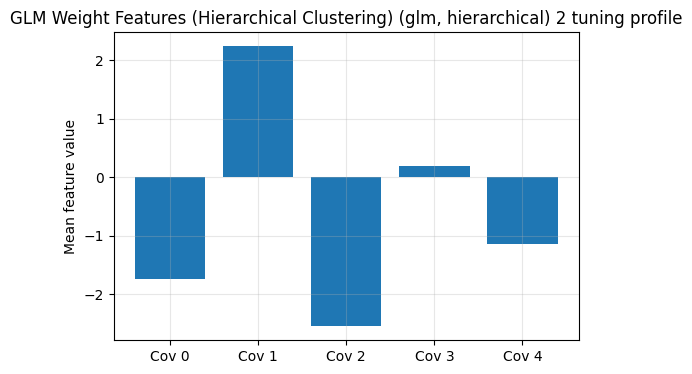

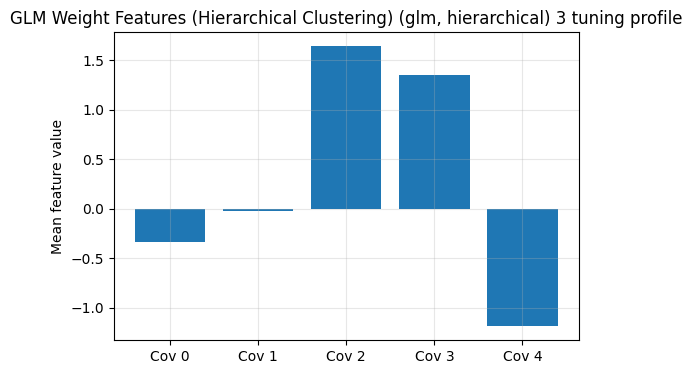

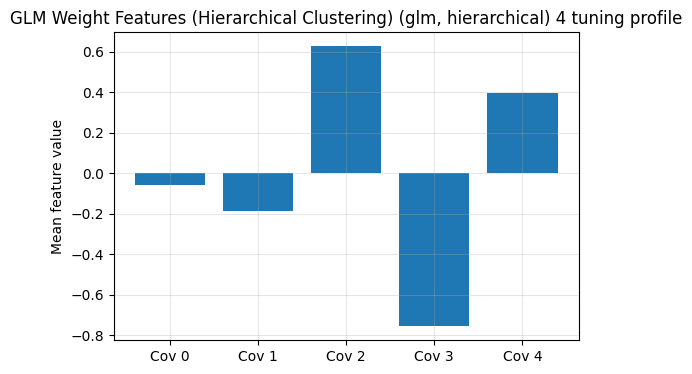

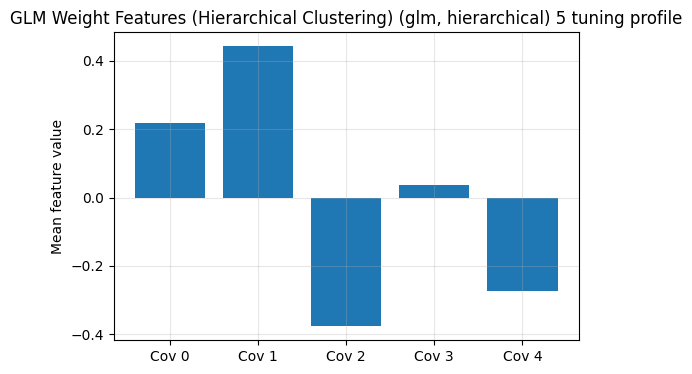

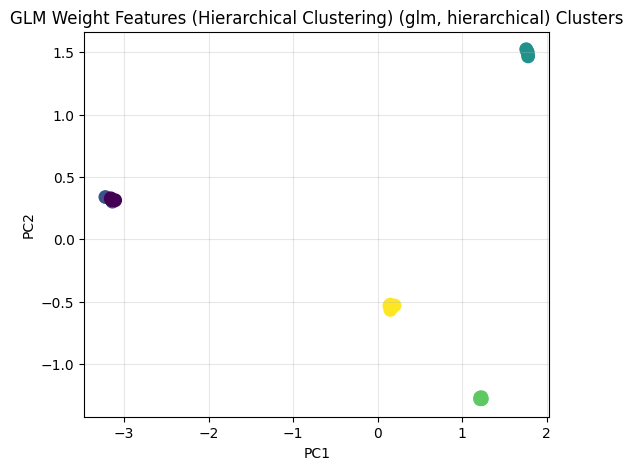

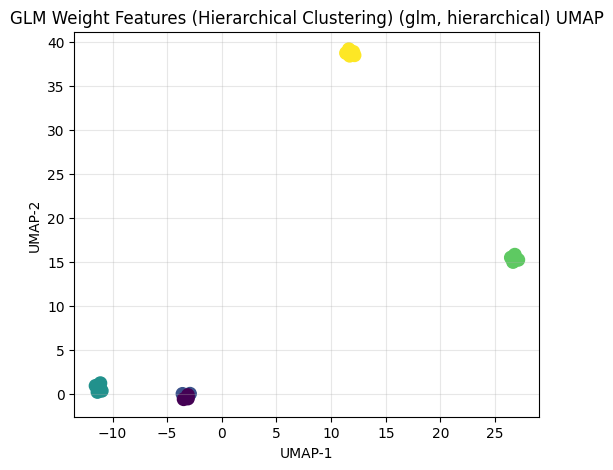

In [28]:
# GLM features + Hierarchical Clustering
results_glm_hier = run_clustering(
    X,
    Y,
    cell_ids,
    rec_ids,
    feature_key="glm",
    cluster_key="hierarchical",
    n_clusters=5,
    title_prefix="GLM Weight Features (Hierarchical Clustering)",
)

results_glm_hier